In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyref.fitting as fit
import os

In [3]:
from utils.profile_slab import AdaptiveBookendedOrientationProfile
from utils.slab_builders import vacuum, sio2, substrate
from utils import read_xrr, read_ooc
from utils.helpers.fitting_helper import package_results


oocs = read_ooc("dft.csv", material="znpc")
data = read_xrr("reflectivity_data", material="znpc")

def model_bookend(
    energy: float,
    density: float = 1.61,
    num_slabs: int = 40,
    tau_si: float = 8,
    tau_vac: float = 10,
    alpha_bulk: float = np.pi / 2,
    alpha_si: float = 0,
    alpha_vac: float = 0,
    surface_roughness: float = 10,
):
    return (
        vacuum(energy)  # pyright: ignore[reportOperatorIssue]
        | AdaptiveBookendedOrientationProfile(
            oocs,
            energy=energy,
            total_thick=200,
            surface_roughness=surface_roughness,
            tau_si=tau_si,
            tau_vac=tau_vac,
            alpha_bulk=alpha_bulk,
            alpha_si=alpha_si,
            alpha_vac=alpha_vac,
            density=density,
            num_slabs=num_slabs,
            name=f"ZnPc_{energy:.1f}",
        )
        | sio2(energy)
        | substrate(energy)
    )

In [18]:
import pyref.fitting as fit
from pyref.fitting import Transform

from utils.slab_builders import select

objective = [
    fit.AnisotropyObjective(
        fit.ReflectModel(model_bookend(250), energy=250),
        data["250.0"],
        logp_anisotropy_weight=0.5,
        transform=Transform("logY"),
    ),
    fit.AnisotropyObjective(
        fit.ReflectModel(model_bookend(275), energy=275),
        data["275.0"],
        logp_anisotropy_weight=0.5,
        transform=Transform("logY"),
    ),
    fit.AnisotropyObjective(
        fit.ReflectModel(model_bookend(283.7), energy=283.7),
        data["283.7"],
        logp_anisotropy_weight=0.5,
        transform=Transform("logY"),
    ),
]


select(objective[0], "Oxide").thick.setp(vary=False)
select(objective[0], "Oxide").rough.setp(vary=False)

select(objective[0], "ZnPc").total_thick.setp(vary=True, bounds=(140, 210))
select(objective[0], "ZnPc").surface_roughness.setp(vary=True, bounds=(0, 50))
select(objective[0], "ZnPc").density.setp(vary=False, bounds=(1, 2))
select(objective[0], "ZnPc").tau_si.setp(vary=True, bounds=(0, 20))
select(objective[0], "ZnPc").tau_vac.setp(vary=True, bounds=(0, 20))
select(objective[0], "ZnPc").alpha_bulk.setp(vary=True, bounds=(0, np.pi / 2))
select(objective[0], "ZnPc").alpha_si.setp(vary=False, bounds=(0, np.pi / 2))
select(objective[0], "ZnPc").alpha_vac.setp(vary=False, bounds=(0, np.pi / 2))
# objective[0].model.energy_offset.setp(vary=True, bounds=(-.5, .5))

for i in range(1, len(objective)):
    select(objective[i], "Oxide").thick.setp(constraint=select(objective[0], "Oxide").thick)
    select(objective[i], "Oxide").rough.setp(constraint=select(objective[0], "Oxide").rough)

    select(objective[i], "ZnPc").total_thick.setp(constraint=select(objective[0], "ZnPc").total_thick)
    select(objective[i], "ZnPc").surface_roughness.setp(constraint=select(objective[0], "ZnPc").surface_roughness)
    select(objective[i], "ZnPc").density.setp(constraint=select(objective[0], "ZnPc").density)
    select(objective[i], "ZnPc").tau_si.setp(constraint=select(objective[0], "ZnPc").tau_si)
    select(objective[i], "ZnPc").tau_vac.setp(constraint=select(objective[0], "ZnPc").tau_vac)
    select(objective[i], "ZnPc").alpha_bulk.setp(constraint=select(objective[0], "ZnPc").alpha_bulk)
    select(objective[i], "ZnPc").alpha_si.setp(constraint=select(objective[0], "ZnPc").alpha_si)
    select(objective[i], "ZnPc").alpha_vac.setp(constraint=select(objective[0], "ZnPc").alpha_vac)
    objective[i].model.energy_offset.setp(constraint=objective[0].model.energy_offset)

for o in objective:
    o.model.scale_p.setp(vary=True, bounds=(.5, 2))
    o.model.scale_s.setp(vary=True, bounds=(.5, 2))
    o.model.theta_offset_p.setp(vary=True, bounds=(-.5, .5))
    o.model.theta_offset_s.setp(vary=True, bounds=(-.5, .5))

fitter = fit.CurveFitter(fit.GlobalObjective(objective))
package_results(fitter)

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,value
name,
scale_s,1.0+/-0
scale_p,1.0+/-0
theta_offset_s,0.0+/-0
theta_offset_p,0.0+/-0
total_thick,200.0+/-0
surface_roughness,0.0+/-0
tau_si,8.0+/-0
tau_vac,10.0+/-0
alpha_bulk,1.5707963267948966+/-0


In [19]:
fitter.fit(method="differential_evolution", updating="deferred", workers=10)
package_results(fitter)

25.271243794472426: : 33it [16:36, 30.20s/it]
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/objective.py:796: LinAlgWarning: The following Parameters have no effect on Objective.residuals, please consider fixing them.
[Parameter(value=0.5, name='scale_s', vary=True, bounds=Interval(lb=0.5, ub=2.0), constraint=None), Parameter(value=-0.059813154209675916, name='theta_offset_p', vary=True, bounds=Interval(lb=-0.5, ub=0.5), constraint=None), Parameter(value=0.5, name='theta_offset_p', vary=True, bounds=Interval(lb=-0.5, ub=0.5), constraint=None)]
  warnings.warn(
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,value
name,
scale_s,0.5+/-0
scale_p,0.520+/-0.004
theta_offset_s,-0.255+/-0.018
theta_offset_p,-0.356053213407608038+/-0.000000000000000017
total_thick,202.99+/-0.12
surface_roughness,4.59+/-0.12
tau_si,14.1+/-1.2
tau_vac,8.9+/-0.6
alpha_bulk,0.623+/-0.008


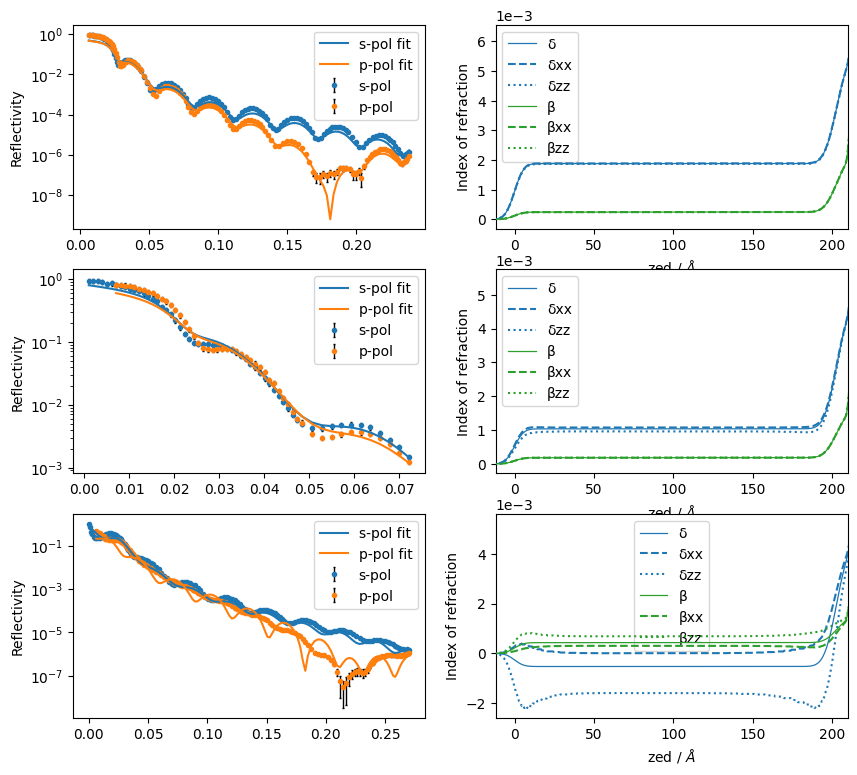

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(10, 9))
for i, o in enumerate(objective):
    o.plot(ax=ax[i,0], show_anisotropy=False)
    o.model.structure.plot(ax=ax[i,1])
    ax[i,1].set_xlim(-12, 210)